# LGBM — Quarterly Expanding Window (5-Day Gap)

**Target**: `target_excess_xfn_5d`  |  **Window**: Expanding  |  **Gap**: 5 td  
**Features**: 15 simple/explainable  |  **Cadence**: Quarterly (~63 td per fold)

In [1]:
import sys
import warnings
import pickle
import json
from pathlib import Path
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import f1_score
from IPython.display import display

warnings.filterwarnings('ignore')

NOTEBOOK_DIR = Path('').resolve()
ROOT = NOTEBOOK_DIR.parents[2]
EXP_PARENT = ROOT / 'step3_predictive_model/model_experiments_archive'
for p in [str(ROOT), str(EXP_PARENT)]:
    if p not in sys.path:
        sys.path.insert(0, p)

ARTIFACT_DIR = NOTEBOOK_DIR / 'artifacts'
ARTIFACT_DIR.mkdir(exist_ok=True)
print(f'ROOT: {ROOT}')

ROOT: /Users/yanyan/Desktop/Projects/AI_driven_company_and_stock_analysis


In [2]:
from redesign_single_stock.src.run_redesign_experiments import load_dataset, label_3class
from src.models.walk_forward_config import STRIDE_EVAL

df = load_dataset()

def call_decay_from_days(days, halflife=20.0):
    return np.exp(-days.clip(lower=0).fillna(999.0) / halflife)

call_decay = call_decay_from_days(df['days_since_call'])
df['evt_exec_tone']         = df[['transcript_ceo_prep_sentiment_mean_ffill',
                                   'transcript_cfo_prep_sentiment_mean_ffill']].mean(axis=1) * call_decay
df['evt_guidance_topic']     = df['topic_guidance_share_ffill'] * call_decay
df['evt_guidance_sentiment'] = df['topic_guidance_sentiment_ffill'] * call_decay
df['evt_aml_topic']          = df['topic_regulatory_AML_share_ffill'] * call_decay
df['evt_aml_sentiment']      = df['topic_regulatory_AML_sentiment_ffill'] * call_decay

FEATURES = [
    'td_return_5d', 'td_return_20d', 'td_vs_xfn_5d', 'td_dist_52w_high',
    'news_sent_mean_30d', 'news_count_30d', 'days_since_last_news',
    'days_since_call', 'is_earnings_week',
    'evt_exec_tone', 'evt_framing_gap',
    'evt_guidance_topic', 'evt_guidance_sentiment',
    'evt_aml_topic', 'evt_aml_sentiment',
]
TARGET    = 'target_excess_xfn_5d'
THRESHOLD = 0.003
LABEL_MAP = {-1: 0, 0: 1, 1: 2}
INV_MAP   = {0: -1, 1: 0, 2: 1}
STRIDE    = STRIDE_EVAL
GAP_DAYS  = 5   # no-touch buffer: target_excess_xfn_5d uses 5-day forward returns

missing = [f for f in FEATURES if f not in df.columns]
assert not missing, f'Missing: {missing}'
print(f'Loaded {len(df)} rows  |  {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Features: {len(FEATURES)}')
print(f'Gap between train_end and test_start: {GAP_DAYS} trading days (target leakage prevention)')

Loaded 1285 rows  |  2021-02-25 to 2026-04-09
Features: 15
Gap between train_end and test_start: 5 trading days (target leakage prevention)


## 1. Define Quarterly Folds (5-Day Gap Applied)

In [3]:
def make_quarterly_expanding_folds(df, target, min_train_days=504, quarter_days=63, gap=GAP_DAYS):
    '''
    Expanding-window quarterly folds.
    gap: trading-day buffer between train_end and test_start to prevent
         label leakage from the 5-day forward return target.
    train ends gap days before test starts; test window = ~1 quarter.
    '''
    dated = df[df[target].notna()].sort_values('date')
    dates = dated['date'].values
    folds = []
    # i = index of first test day; train ends at i-1-gap
    i, fold_id = min_train_days + gap, 1
    while i < len(dates):
        te_end_i      = min(i + quarter_days - 1, len(dates) - 1)
        train_end_idx = i - 1 - gap          # last safe training day
        folds.append((
            fold_id,
            str(dates[0])[:10],              # train_start (always beginning)
            str(dates[train_end_idx])[:10],  # train_end (gap days before test)
            str(dates[i])[:10],              # test_start
            str(dates[te_end_i])[:10],       # test_end
        ))
        i = te_end_i + 1
        fold_id += 1
    return folds

FOLDS = make_quarterly_expanding_folds(df, TARGET)

print(f'Total quarterly folds: {len(FOLDS)}')
print(f'Gap applied: {GAP_DAYS} trading days between train_end and test_start')
print(f'{"Fold":<6} {"Train start":<13} {"Train end":<13} {"Test start":<13} {"Test end":<13} {"Gap":>5} {"Test rows":>9}')
print('-' * 72)
for fold_id, tr_s, tr_e, te_s, te_e in FOLDS:
    dated_te = df[(df['date'] >= pd.Timestamp(te_s)) &
                  (df['date'] <= pd.Timestamp(te_e)) & df[TARGET].notna()]
    gap_days = (pd.Timestamp(te_s) - pd.Timestamp(tr_e)).days
    print(f'{fold_id:<6} {tr_s:<13} {tr_e:<13} {te_s:<13} {te_e:<13} {gap_days:>5} {len(dated_te):>9}')

Total quarterly folds: 13
Gap applied: 5 trading days between train_end and test_start
Fold   Train start   Train end     Test start    Test end        Gap Test rows
------------------------------------------------------------------------
1      2021-02-25    2023-02-28    2023-03-08    2023-06-06        8        63
2      2021-02-25    2023-05-30    2023-06-07    2023-09-06        8        63
3      2021-02-25    2023-08-29    2023-09-07    2023-12-05        9        63
4      2021-02-25    2023-11-28    2023-12-06    2024-03-07        8        63
5      2021-02-25    2024-02-29    2024-03-08    2024-06-06        8        63
6      2021-02-25    2024-05-30    2024-06-07    2024-09-06        8        63
7      2021-02-25    2024-08-29    2024-09-09    2024-12-05       11        63
8      2021-02-25    2024-11-28    2024-12-06    2025-03-10        8        63
9      2021-02-25    2025-03-03    2025-03-11    2025-06-09        8        63
10     2021-02-25    2025-06-02    2025-06-10    2

## 2. Hyperparameter Grid Search

In [4]:
import lightgbm as lgb

def fit_lgbm(train_df, test_df, params):
    x_tr  = train_df[FEATURES].fillna(train_df[FEATURES].median())
    y_tr  = label_3class(train_df[TARGET].values, threshold=THRESHOLD)
    y_enc = np.array([LABEL_MAP[v] for v in y_tr], dtype=int)
    clf = lgb.LGBMClassifier(objective='multiclass', num_class=3,
                             random_state=42, verbose=-1, n_jobs=1, **params)
    clf.fit(x_tr, y_enc)
    x_te      = test_df[FEATURES].fillna(train_df[FEATURES].median())
    y_te_cls  = label_3class(test_df[TARGET].values, threshold=THRESHOLD)
    y_te_cont = test_df[TARGET].values
    preds     = np.array([INV_MAP[p] for p in clf.predict(x_te)])
    return clf, preds, y_te_cls, y_te_cont

print('fit_lgbm defined.')

fit_lgbm defined.


In [5]:
def offset_metrics(preds, y_true_cls, y_true_cont):
    rows = []
    for off in range(STRIDE):
        idx = np.arange(off, len(preds), STRIDE)
        p, y_cls, y_cont = preds[idx], y_true_cls[idx], y_true_cont[idx]
        active = (p != 0)
        rows.append({
            'mean_acc':   (p == y_cls).mean(),
            'macro_f1':   f1_score(y_cls, p, average='macro', zero_division=0, labels=[-1, 0, 1]),
            'active_cov': active.mean(),
            'active_asa': float((np.sign(p[active]) == np.sign(y_cont[active])).mean())
                          if active.sum() > 0 else np.nan,
        })
    return pd.DataFrame(rows).mean()

print('offset_metrics defined.')

offset_metrics defined.


In [6]:
n_folds    = len(FOLDS)
tune_start = max(2, n_folds // 4)
tune_end   = min(n_folds - 2, n_folds * 3 // 4)
TUNE_FOLDS = FOLDS[tune_start : tune_end + 1]
print(f'Tuning on folds {tune_start+1}..{tune_end+1} ({len(TUNE_FOLDS)} folds) out of {n_folds} total')

GRID = {
    'num_leaves':        [4, 8, 16],
    'min_child_samples': [20, 40, 80],
    'n_estimators':      [100, 200, 300],
    'learning_rate':     [0.05],
    'feature_fraction':  [0.8],
    'reg_alpha':         [0.2],
    'reg_lambda':        [1.0],
}

from itertools import product as iproduct
param_combos = list(iproduct(GRID['num_leaves'], GRID['min_child_samples'], GRID['n_estimators']))
print(f'Grid size: {len(param_combos)} configs x {len(TUNE_FOLDS)} tuning folds')

search_rows = []
for nl, mcs, ne in param_combos:
    params = dict(num_leaves=nl, min_child_samples=mcs, n_estimators=ne,
                  learning_rate=0.05, feature_fraction=0.8, reg_alpha=0.2, reg_lambda=1.0)
    fold_metrics = []
    for fold_id, tr_s, tr_e, te_s, te_e in TUNE_FOLDS:
        train_df = df[(df['date'] >= pd.Timestamp(tr_s)) &
                      (df['date'] <= pd.Timestamp(tr_e)) & df[TARGET].notna()]
        test_df  = df[(df['date'] >= pd.Timestamp(te_s)) &
                      (df['date'] <= pd.Timestamp(te_e)) & df[TARGET].notna()]
        if len(test_df) < 10:
            continue
        _, preds, y_cls, y_cont = fit_lgbm(train_df, test_df, params)
        fold_metrics.append(offset_metrics(preds, y_cls, y_cont))
    if not fold_metrics:
        continue
    agg = pd.DataFrame(fold_metrics).mean()
    search_rows.append({'num_leaves': nl, 'min_child_samples': mcs, 'n_estimators': ne,
                        'active_asa': agg['active_asa'], 'macro_f1': agg['macro_f1'],
                        'active_cov': agg['active_cov'],
                        'composite': 0.6 * agg['active_asa'] + 0.4 * agg['macro_f1']})

search_df = pd.DataFrame(search_rows).sort_values('composite', ascending=False)
best_row  = search_df.iloc[0]
BEST_PARAMS = dict(num_leaves=int(best_row.num_leaves), min_child_samples=int(best_row.min_child_samples),
                   n_estimators=int(best_row.n_estimators),
                   learning_rate=0.05, feature_fraction=0.8, reg_alpha=0.2, reg_lambda=1.0)
print('=== Top-5 configs ===')
display(search_df.head(5).round(4))
print(f'\nBest params: {BEST_PARAMS}')
print(f'Best composite: {best_row.composite:.4f}')

Tuning on folds 4..10 (7 folds) out of 13 total
Grid size: 27 configs x 7 tuning folds


=== Top-5 configs ===


,num_leaves,min_child_samples,n_estimators,active_asa,macro_f1,active_cov,composite
21,16,40,100,0.5255,0.3240,0.9447,0.4449
3,4,40,100,0.5306,0.3123,0.9703,0.4433
4,4,40,200,0.5267,0.3097,0.9522,0.4399
24,16,80,100,0.5224,0.2954,0.9679,0.4316
12,8,40,100,0.5199,0.2975,0.9610,0.4310



Best params: {'num_leaves': 16, 'min_child_samples': 40, 'n_estimators': 100, 'learning_rate': 0.05, 'feature_fraction': 0.8, 'reg_alpha': 0.2, 'reg_lambda': 1.0}
Best composite: 0.4449


## 3. Full Walk-Forward Evaluation

In [7]:
fold_results       = []
fold_models        = []
fold_x_te_list     = []
fold_sv_out_list   = []
fold_sv_under_list = []
fold_shap_out_dfs   = []
fold_shap_under_dfs = []

print('Running full walk-forward on all quarterly folds...')
for fold_id, tr_s, tr_e, te_s, te_e in FOLDS:
    train_df = df[(df['date'] >= pd.Timestamp(tr_s)) &
                  (df['date'] <= pd.Timestamp(tr_e)) & df[TARGET].notna()]
    test_df  = df[(df['date'] >= pd.Timestamp(te_s)) &
                  (df['date'] <= pd.Timestamp(te_e)) & df[TARGET].notna()]
    if len(test_df) < 5:
        continue

    clf, preds, y_cls, y_cont = fit_lgbm(train_df, test_df, BEST_PARAMS)
    m = offset_metrics(preds, y_cls, y_cont)

    explainer = shap.TreeExplainer(clf)
    x_te_cl   = test_df[FEATURES].fillna(train_df[FEATURES].median())
    sv = explainer.shap_values(x_te_cl)
    if isinstance(sv, list):
        sv_out, sv_under = sv[2], sv[0]
    else:
        sv_arr = np.array(sv)
        if sv_arr.ndim == 3 and sv_arr.shape[-1] == 3:
            sv_out, sv_under = sv_arr[:, :, 2], sv_arr[:, :, 0]
        else:
            sv_out = sv_under = sv_arr

    fold_sv_out_list.append(sv_out)
    fold_sv_under_list.append(sv_under)
    fold_x_te_list.append(x_te_cl.reset_index(drop=True))
    fold_shap_out_dfs.append(pd.Series(np.abs(sv_out).mean(axis=0), index=FEATURES, name=fold_id))
    fold_shap_under_dfs.append(pd.Series(np.abs(sv_under).mean(axis=0), index=FEATURES, name=fold_id))

    fold_results.append({'fold': fold_id, 'train_rows': len(train_df), 'test_rows': len(test_df),
                          'train_end': tr_e, 'test_start': te_s, 'test_end': te_e, **m.to_dict()})
    fold_models.append(clf)
    print(f'Fold {fold_id:>2}  acc={m["mean_acc"]:.3f}  asa={m["active_asa"]:.3f}  cov={m["active_cov"]:.3f}')

results_df = pd.DataFrame(fold_results).set_index('fold')
print(f'\nDone. {len(results_df)} folds evaluated.')

Running full walk-forward on all quarterly folds...
Fold  1  acc=0.254  asa=0.347  cov=0.796
Fold  2  acc=0.399  asa=0.560  cov=0.871


Fold  3  acc=0.413  asa=0.580  cov=0.951
Fold  4  acc=0.367  asa=0.465  cov=0.921


Fold  5  acc=0.556  asa=0.621  cov=0.903
Fold  6  acc=0.491  asa=0.682  cov=0.951


Fold  7  acc=0.462  asa=0.517  cov=0.985
Fold  8  acc=0.332  asa=0.373  cov=0.967


Fold  9  acc=0.382  asa=0.475  cov=0.904
Fold 10  acc=0.363  asa=0.545  cov=0.983


Fold 11  acc=0.365  asa=0.491  cov=0.938
Fold 12  acc=0.381  asa=0.502  cov=0.922


Fold 13  acc=0.250  asa=0.450  cov=1.000

Done. 13 folds evaluated.


## 4. Performance Summary

=== Per-Fold Performance ===


,train_rows,test_rows,mean_acc,macro_f1,active_cov,active_asa
fold,,,,,,
1,504,63,0.254,0.192,0.796,0.347
2,567,63,0.399,0.323,0.871,0.560
3,630,63,0.413,0.313,0.951,0.580
4,693,63,0.367,0.252,0.921,0.465
5,756,63,0.556,0.505,0.903,0.621
6,819,63,0.491,0.397,0.951,0.682
7,882,63,0.462,0.330,0.985,0.517
8,945,63,0.332,0.220,0.967,0.373
9,1008,63,0.382,0.274,0.904,0.475



=== Aggregate (mean across all folds) ===
  Mean accuracy   : 0.386
  Macro F1        : 0.299
  Active coverage : 0.930
  Active ASA      : 0.508
  Composite       : 0.4245  (0.6xASA + 0.4xF1)
  DirAcc_strict    : 0.474
  DirAcc_abstain50 : 0.509


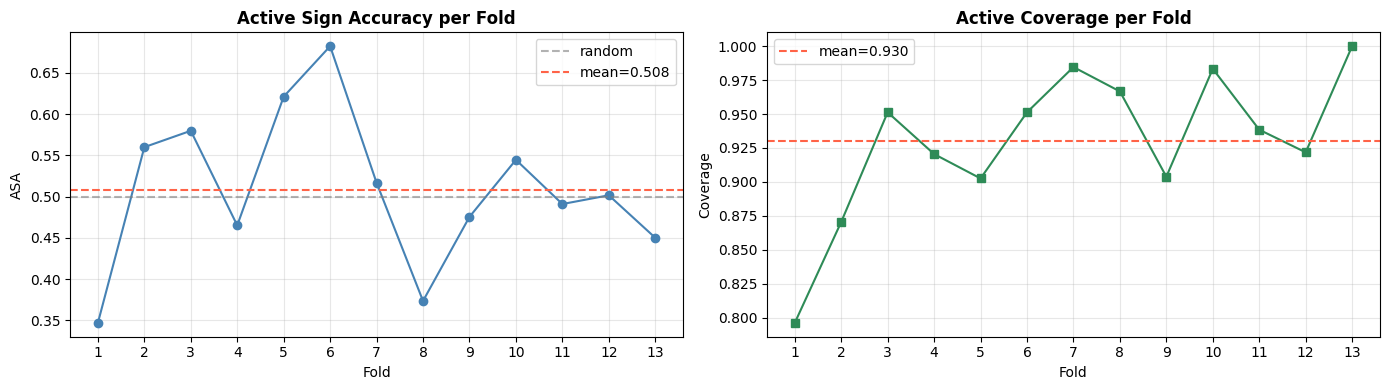

In [8]:
display_cols = ['train_rows', 'test_rows', 'mean_acc', 'macro_f1', 'active_cov', 'active_asa']

print('=== Per-Fold Performance ===')
display(results_df[display_cols].round(3))

means = results_df[display_cols].mean()
composite = 0.6 * means['active_asa'] + 0.4 * means['macro_f1']
print('\n=== Aggregate (mean across all folds) ===')
print(f'  Mean accuracy   : {means["mean_acc"]:.3f}')
print(f'  Macro F1        : {means["macro_f1"]:.3f}')
print(f'  Active coverage : {means["active_cov"]:.3f}')
print(f'  Active ASA      : {means["active_asa"]:.3f}')
print(f'  Composite       : {composite:.4f}  (0.6xASA + 0.4xF1)')

results_df['DirAcc_strict']    = results_df['active_asa'] * results_df['active_cov']
results_df['DirAcc_abstain50'] = (results_df['active_asa'] * results_df['active_cov']
                                   + 0.5 * (1 - results_df['active_cov']))
print(f'  DirAcc_strict    : {results_df["DirAcc_strict"].mean():.3f}')
print(f'  DirAcc_abstain50 : {results_df["DirAcc_abstain50"].mean():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(results_df.index.astype(str), results_df['active_asa'], marker='o', color='steelblue')
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='random')
axes[0].axhline(results_df['active_asa'].mean(), color='tomato', linestyle='--',
                label=f'mean={results_df["active_asa"].mean():.3f}')
axes[0].set_title('Active Sign Accuracy per Fold', fontweight='bold')
axes[0].set_ylabel('ASA'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(results_df.index.astype(str), results_df['active_cov'], marker='s', color='seagreen')
axes[1].axhline(results_df['active_cov'].mean(), color='tomato', linestyle='--',
                label=f'mean={results_df["active_cov"].mean():.3f}')
axes[1].set_title('Active Coverage per Fold', fontweight='bold')
axes[1].set_ylabel('Coverage'); axes[1].legend(); axes[1].grid(alpha=0.3)

for ax in axes:
    ax.set_xlabel('Fold')

plt.tight_layout()
plt.show()

## 5. SHAP Global Importance & Fold Stability

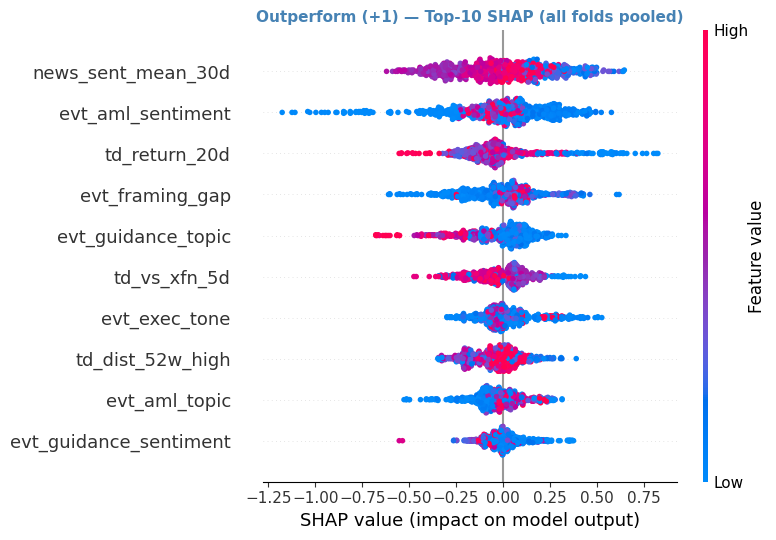

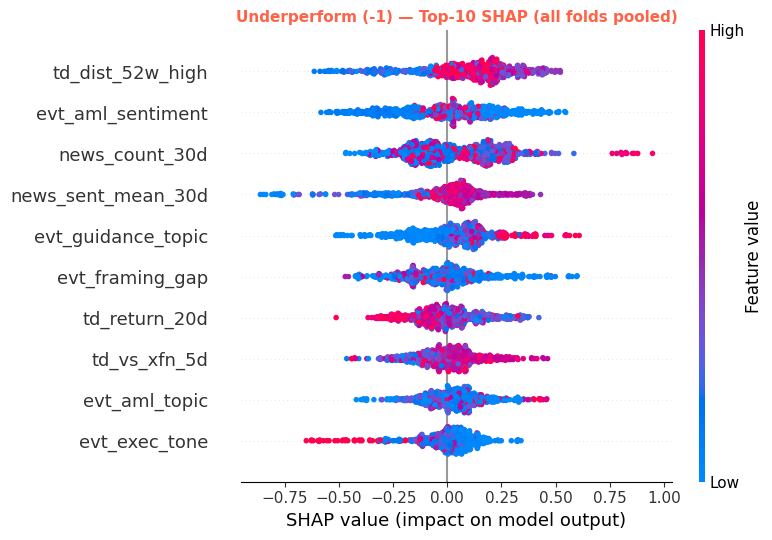

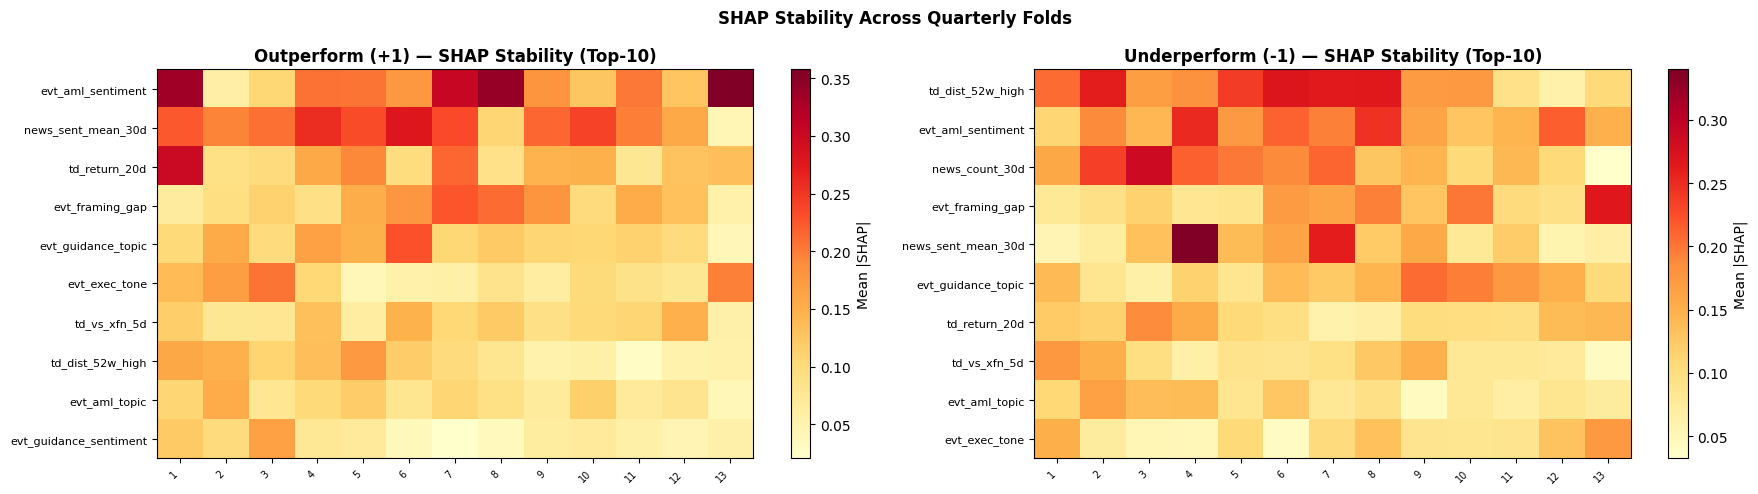

Top-10 Outperform:
evt_aml_sentiment         0.2095
news_sent_mean_30d        0.1993
td_return_20d             0.1432
evt_framing_gap           0.1334
evt_guidance_topic        0.1222
evt_exec_tone             0.1050
td_vs_xfn_5d              0.1025
td_dist_52w_high          0.0963
evt_aml_topic             0.0926
evt_guidance_sentiment    0.0698

Top-10 Underperform:
td_dist_52w_high      0.1889
evt_aml_sentiment     0.1782
news_count_30d        0.1650
evt_framing_gap       0.1368
news_sent_mean_30d    0.1353
evt_guidance_topic    0.1328
td_return_20d         0.1142
td_vs_xfn_5d          0.1013
evt_aml_topic         0.0988
evt_exec_tone         0.0982


In [9]:
df_shap_out   = pd.DataFrame(fold_shap_out_dfs)
df_shap_under = pd.DataFrame(fold_shap_under_dfs)
imp_out   = df_shap_out.mean().sort_values(ascending=False)
imp_under = df_shap_under.mean().sort_values(ascending=False)

all_sv_out   = np.vstack(fold_sv_out_list)
all_sv_under = np.vstack(fold_sv_under_list)
all_x_te     = pd.concat(fold_x_te_list, ignore_index=True)

for sv_all, imp_cls, label, color in [
    (all_sv_out,   imp_out,   'Outperform (+1)',   'steelblue'),
    (all_sv_under, imp_under, 'Underperform (-1)', 'tomato'),
]:
    top10 = imp_cls.head(10).index.tolist()
    idx   = [FEATURES.index(f) for f in top10]
    plt.figure(figsize=(12, 6))
    shap.summary_plot(sv_all[:, idx], all_x_te[top10], feature_names=top10,
                      plot_type='dot', max_display=10, show=False, color_bar=True)
    plt.title(f'{label} — Top-10 SHAP (all folds pooled)', fontsize=11,
              fontweight='bold', color=color)
    plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, df_cls, imp_cls, label in [
    (axes[0], df_shap_out,   imp_out,   'Outperform (+1)'),
    (axes[1], df_shap_under, imp_under, 'Underperform (-1)'),
]:
    top  = imp_cls.head(10).index.tolist()
    heat = df_cls[top].T
    im = ax.imshow(heat.values, aspect='auto', cmap='YlOrRd')
    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels([str(c) for c in heat.columns], rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top, fontsize=8)
    ax.set_title(f'{label} — SHAP Stability (Top-10)', fontweight='bold')
    plt.colorbar(im, ax=ax, label='Mean |SHAP|')
plt.suptitle('SHAP Stability Across Quarterly Folds', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print('Top-10 Outperform:');  print(imp_out.head(10).round(4).to_string())
print('\nTop-10 Underperform:'); print(imp_under.head(10).round(4).to_string())

## 6. Save Artifact

In [10]:
TODAY       = date.today().isoformat()
ARTIFACT_ID = f'lgbm_quarterly_expanding-{TODAY}'
PKL_PATH    = ARTIFACT_DIR / f'{ARTIFACT_ID}.pkl'
JSON_PATH   = ARTIFACT_DIR / f'{ARTIFACT_ID}.json'

means     = results_df[['mean_acc','macro_f1','active_cov','active_asa']].mean()
composite = float(0.6 * means['active_asa'] + 0.4 * means['macro_f1'])

artifact = {
    'features':           FEATURES,
    'target':             TARGET,
    'threshold':          THRESHOLD,
    'label_map':          LABEL_MAP,
    'inverse_label_map':  INV_MAP,
    'best_params':        BEST_PARAMS,
    'window_type':        'expanding_quarterly',
    'gap_days':           GAP_DAYS,
    'n_folds_evaluated':  len(results_df),
    'performance_summary': {
        'mean_acc':   float(means['mean_acc']),
        'macro_f1':   float(means['macro_f1']),
        'active_cov': float(means['active_cov']),
        'active_asa': float(means['active_asa']),
        'composite':  composite,
    },
}
with open(PKL_PATH, 'wb') as f:
    pickle.dump(artifact, f)

meta = {
    'artifact_id':        ARTIFACT_ID,
    'model_name':         'lgbm_quarterly_expanding',
    'window_type':        'expanding_quarterly',
    'gap_days':           GAP_DAYS,
    'created':            TODAY,
    'best_params':        BEST_PARAMS,
    'features':           FEATURES,
    'target':             TARGET,
    'threshold':          THRESHOLD,
    'n_folds_evaluated':  int(len(results_df)),
    'performance_summary': artifact['performance_summary'],
}
with open(JSON_PATH, 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Saved: {PKL_PATH.name}')
print(f'Saved: {JSON_PATH.name}')
print(f'Composite score: {composite:.4f}')
print(f'Gap applied    : {GAP_DAYS} trading days')

Saved: lgbm_quarterly_expanding-2026-04-23.pkl
Saved: lgbm_quarterly_expanding-2026-04-23.json
Composite score: 0.4245
Gap applied    : 5 trading days
